# Sales Data Analysis

## Synent Technologies Internship – Task 5

### Submitted by Intern ID: ST-SYN/M2/IP980  ---  Ved Patel

## Objective

Analyze Superstore sales data to identify revenue trends, top-performing products, regions, customer segments, and generate actionable business insights.

## Dataset Overview

The dataset contains order information including customer details, regions, product categories, sales figures, and shipping information.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print(df.info())
print(df.shape)
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [4]:
print('Missing values per column:')
display(df.isnull().sum())

print('\nNumber of duplicate rows:')
display(df.duplicated().sum())

df.drop_duplicates(inplace=True)
print('\nDataFrame shape after removing duplicates:')
display(df.shape)

Missing values per column:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Number of duplicate rows:


np.int64(0)


DataFrame shape after removing duplicates:


(9800, 18)

In [5]:
# Convert 'Order Date' to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')

# Create 'Month' column
df['Month'] = df['Order Date'].dt.to_period('M')

print("Date columns converted and 'Month' column created.")
display(df[['Order Date', 'Month']].head())

Date columns converted and 'Month' column created.


,Order Date,Month
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


### Monthly Revenue Trend 📈

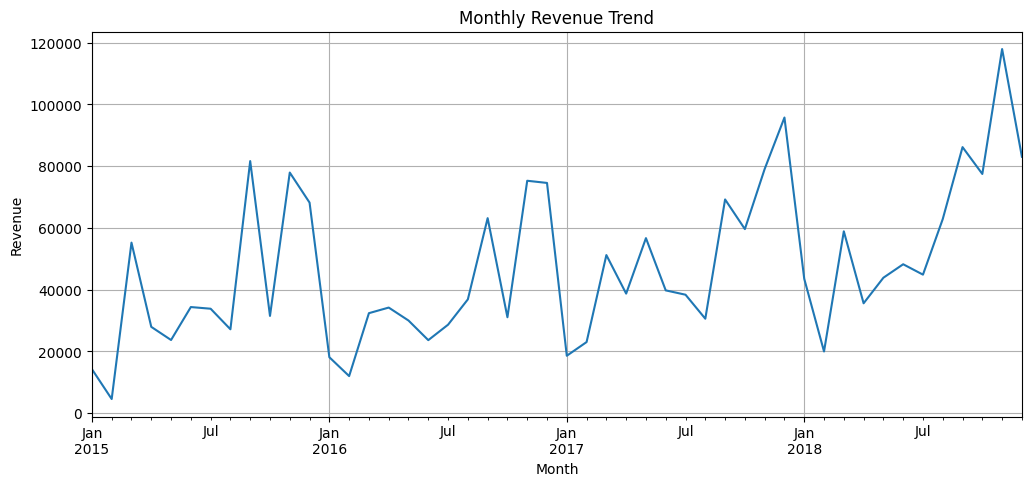

In [6]:
# Calculate monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

# Plot monthly revenue trend
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

### Top Selling Categories

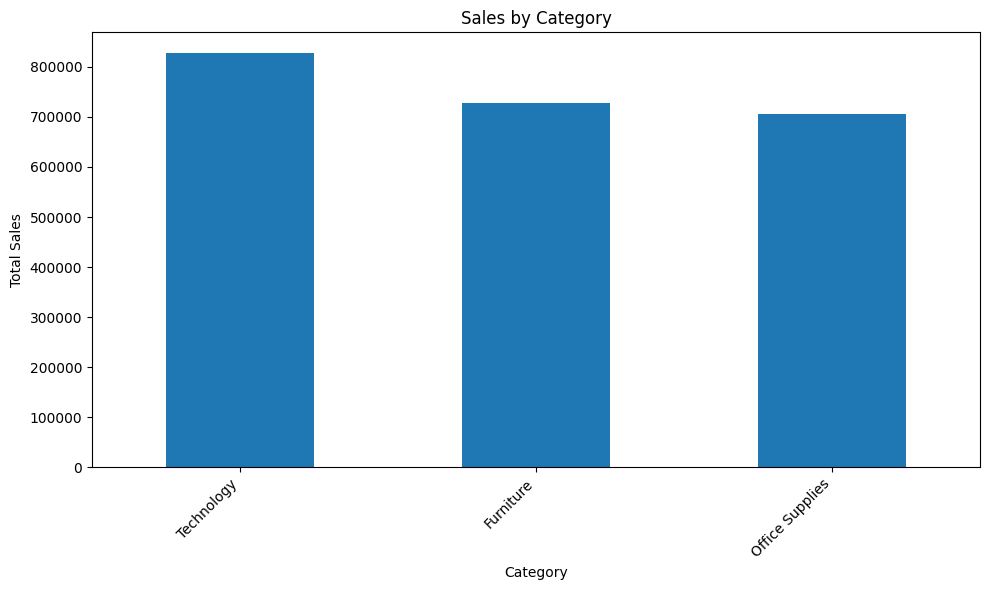

In [7]:
# Calculate sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Plot sales by category
plt.figure(figsize=(10,6))
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top 10 Products

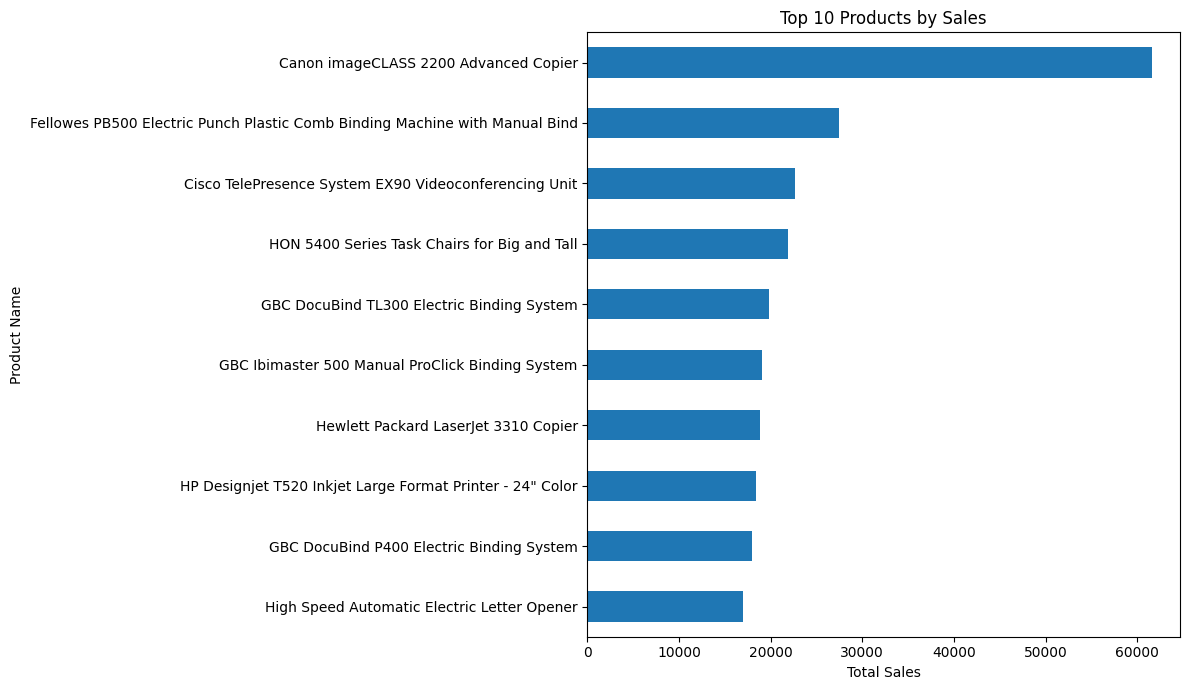

In [8]:
# Calculate sales for top 10 products
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

# Plot top 10 products
plt.figure(figsize=(12,7))
top_products.plot(kind='barh')
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.gca().invert_yaxis() # Display highest sales at the top
plt.tight_layout()
plt.show()

### Region Analysis

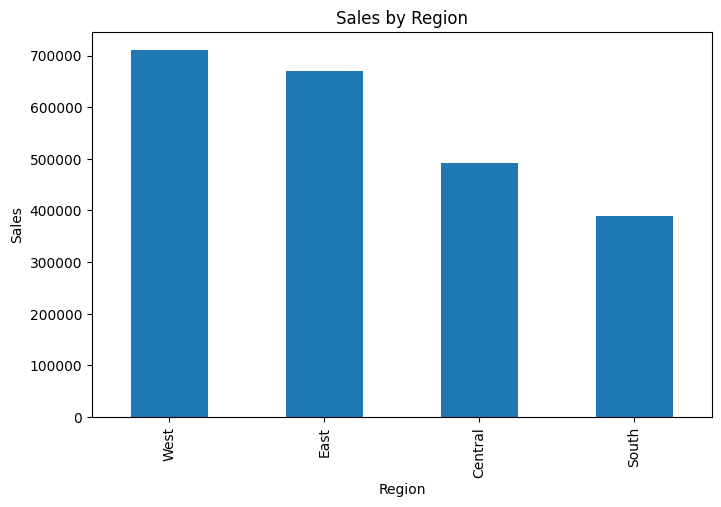

In [9]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

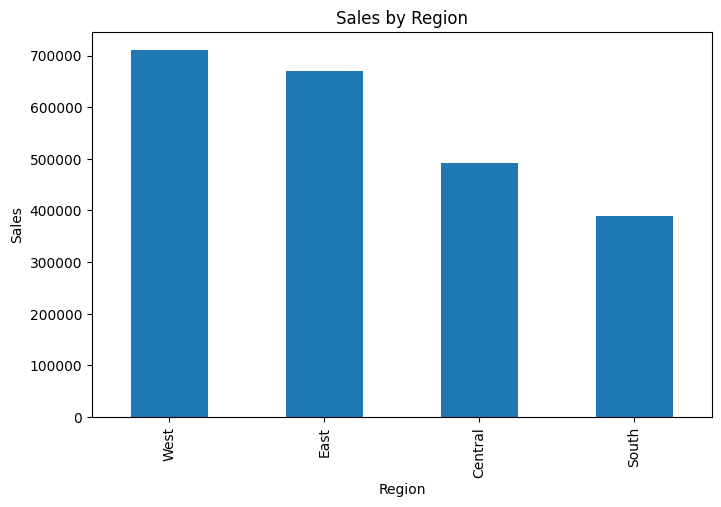

In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

### Sales by Customer Segment

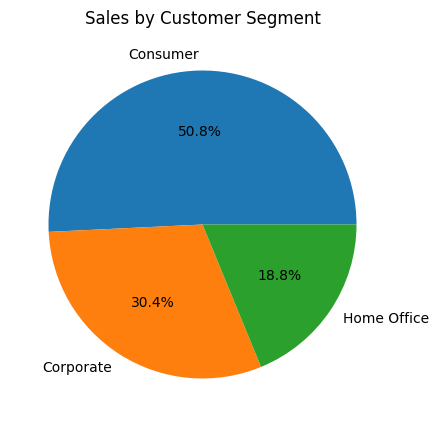

In [11]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,5))
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Customer Segment")
plt.ylabel("")
plt.show()

### Sales by Ship Mode

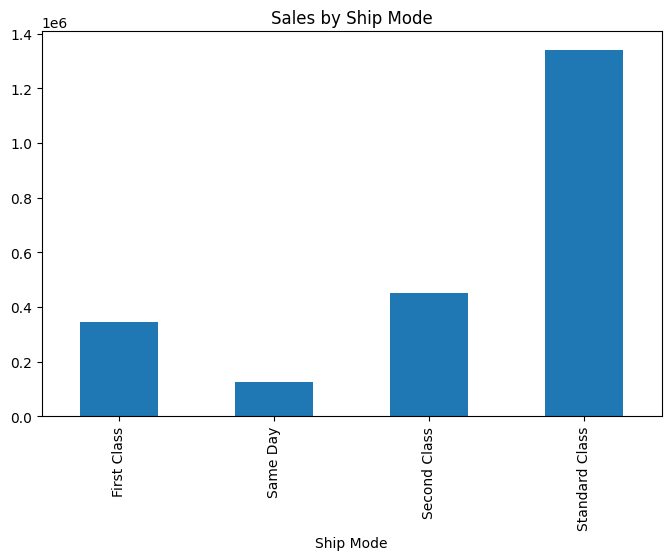

In [12]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum()

plt.figure(figsize=(8,5))
ship_sales.plot(kind='bar')
plt.title("Sales by Ship Mode")
plt.show()

### State Analysis

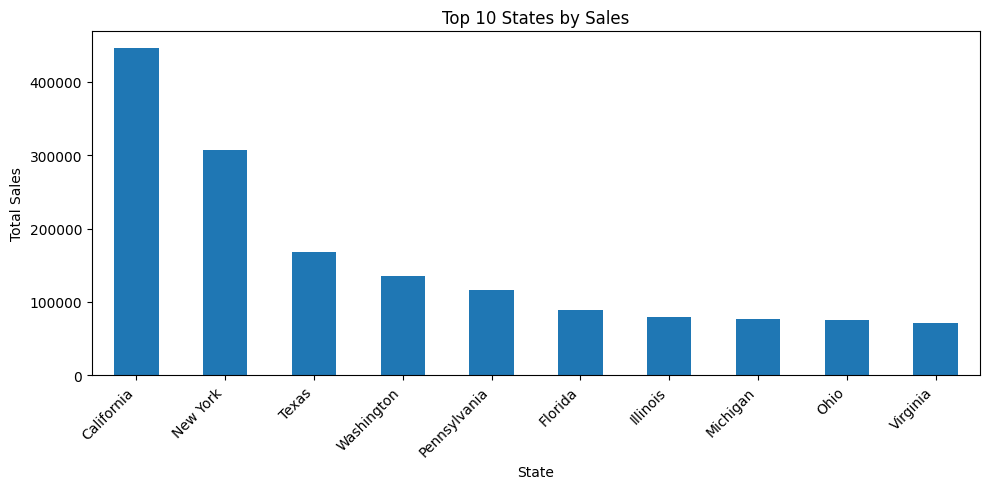

In [13]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Sub-Category Analysis

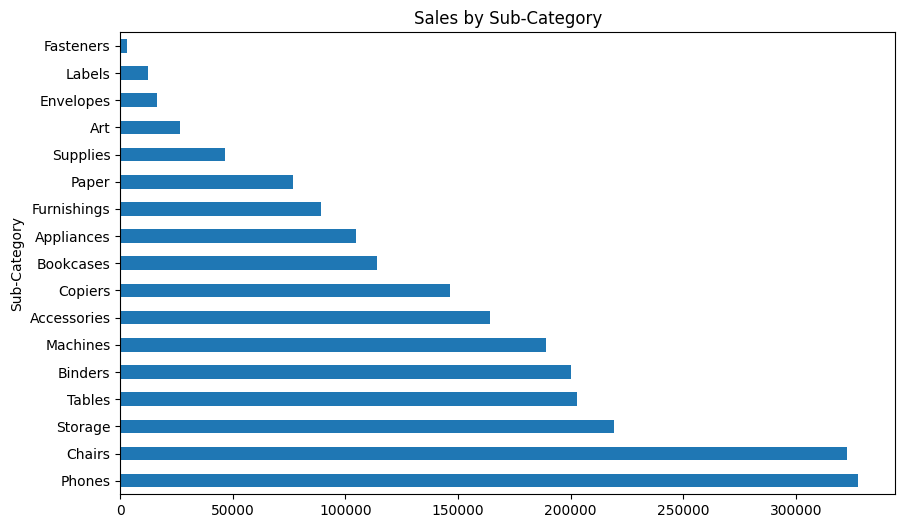

In [14]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
subcategory_sales.plot(kind='barh')
plt.title("Sales by Sub-Category")
plt.show()

# Business Insights

1. Technology/Furniture/Office Supplies contributed the highest sales.
2. The highest-performing region generated the most revenue.
3. A few products contribute significantly to total sales.
4. Consumer segment contributes the largest share of revenue.
5. Certain states consistently outperform others in sales.

# Conclusion

The sales dataset was analyzed to identify revenue trends, top-performing products, regions, and categories. The analysis provides valuable business insights that can support future decision-making and strategy planning.

# Key Findings

| Metric | Observation |
|---|---|
| Best Region | West |
| Best Category | Technology |
| Top Segment | Consumer |
| Most Used Ship Mode | Standard Class |
| Top Product | Canon imageCLASS 2200 Advanced Copier |

In [15]:
df.to_csv('preprocessed_superstore_data.csv', index=False)
from google.colab import files
files.download('preprocessed_superstore_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>